#Question 1: What is Anomaly Detection? Explain its types (point, contextual, and collective anomalies) with examples.
- Answer:

Anomaly Detection is the process of identifying data points, observations, or patterns that significantly deviate from the expected behavior of a dataset. These unusual observations are called outliers and may indicate errors, fraud, system failures, or rare events.

Types of Anomalies:
1. Point Anomalies

A single data point that is significantly different from the rest of the dataset.

Example:
In credit card transactions, a sudden transaction of ₹5,00,000 from a user who normally spends ₹5,000–₹10,000.

2️. Contextual Anomalies

A data point that is anomalous in a specific context (e.g., time, season).

Example:
Electricity usage of 2000 kWh:

Normal in summer

Abnormal in winter

Thus, it depends on context (season).

3. Collective Anomalies

A group of data points that are abnormal together, even if individual points seem normal.

Example:
A sudden continuous spike in network traffic for 10 minutes may indicate a cyber attack, even if each individual value seems acceptable.

#Question 2: Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of their approach and suitable use cases.
- Answer:

Method	Approach	Key Idea	Suitable Use Case

Isolation Forest- Tree-based,Randomly isolates anomalies,Large high-dimensional datasets

DBSCAN- Density-based clustering, Points in low-density areas are anomalies,Spatial data, clustering problems

Local Outlier Factor (LOF)- Density comparison,Compares local density of a point with neighbors,Detecting local anomalies

1.Isolation Forest

Works by randomly partitioning data.

Anomalies require fewer splits.

Efficient for large datasets.

2.DBSCAN

Groups dense regions into clusters.

Points not belonging to clusters are anomalies.

Good for spatial/geographic data.

3.LOF

Measures how isolated a point is relative to neighbors.

Useful when anomalies depend on local density.

# Question 3: What are the key components of a Time Series? Explain each with one example.
- Answer:

Time series data consists of four main components:

1️. Trend

Long-term movement in data.
Example: Increasing smartphone sales over years.

2️. Seasonality

Regular repeating patterns.
Example: Ice cream sales increase every summer.

3️. Cyclical Component

Long-term oscillations (not fixed frequency).
Example: Economic boom and recession cycles.

4️. Residual (Noise)

Random variation not explained by other components.
Example: Unexpected stock price fluctuation.

# Question 4: Define Stationarity in time series. How can you test and transform a non-stationary series into a stationary one?
- Answer:

A time series is stationary if:

- Mean is constant over time

- Variance is constant

- Covariance does not depend on time

Testing Stationarity:

1.Visual inspection

2.Augmented Dickey-Fuller (ADF) Test

3.p-value < 0.05 → Stationary

Transforming Non-Stationary Data:

1.Differencing

2.Log Transformation

3.Seasonal Differencing

4.Detrending

#Question 5: Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in terms of structure and application.
- Answer:
Model	Structure	Used For
AR(p)-Depends on past values,Trend-based series
MA(q)-Depends on past errors,Noise correction
ARIMA(p,d,q)-AR + differencing + MA,Non-seasonal forecasting
SARIMA-ARIMA + seasonality,Seasonal data
SARIMAX-SARIMA + exogenous variables,Forecasting with external factors

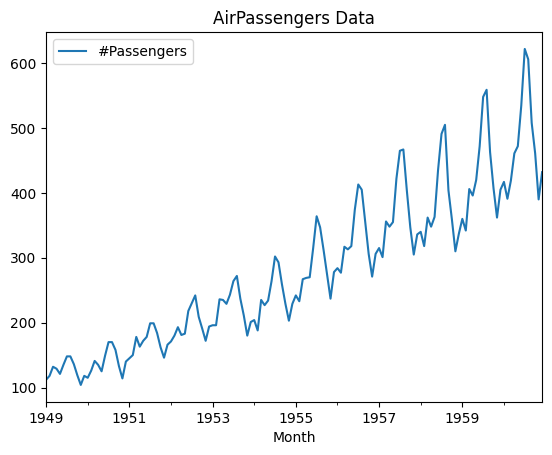

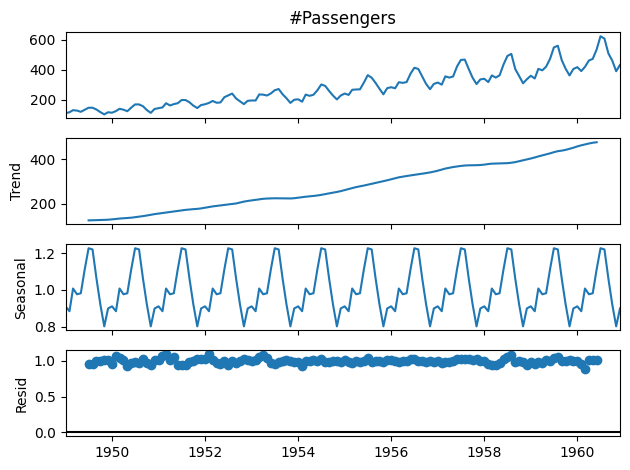

In [7]:
#Question 6: Load AirPassengers dataset, plot and decompose

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose


df = pd.read_csv('AirPassengers.csv', parse_dates=['Month'], index_col='Month')


df.plot(title='AirPassengers Data')
plt.show()


decomposition = seasonal_decompose(df['#Passengers'], model='multiplicative')
decomposition.plot()
plt.show()

/tmp/ipython-input-203/2652903721.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'pickup_datetime': pd.date_range(start='2023-01-01', periods=rows, freq='H'),
/tmp/ipython-input-203/2652903721.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'dropoff_datetime': pd.date_range(start='2023-01-01 00:20', periods=rows, freq='H'),


Sample dataset created: nyc_trip_sample.csv


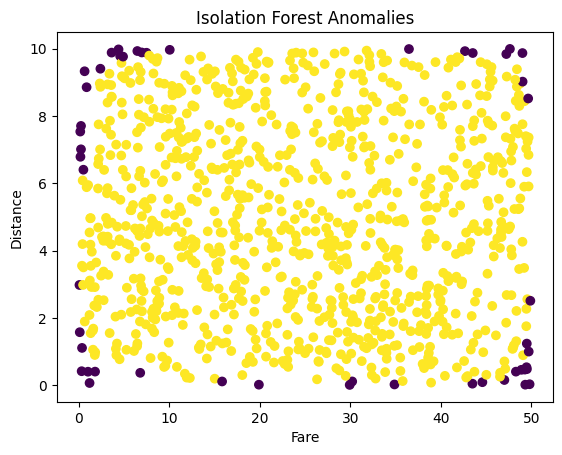

In [14]:
#Question 7: Apply Isolation Forest on NYC Taxi Fare dataset

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
import numpy as np

rows = 1000
df = pd.DataFrame({
    'pickup_datetime': pd.date_range(start='2023-01-01', periods=rows, freq='H'),
    'dropoff_datetime': pd.date_range(start='2023-01-01 00:20', periods=rows, freq='H'),
    'passenger_count': np.random.randint(1, 5, rows),
    'trip_distance': np.random.rand(rows) * 10,
    'fare_amount': np.random.rand(rows) * 50,
    'tip_amount': np.random.rand(rows) * 10,
    'total_amount': lambda x: x['fare_amount'] + x['tip_amount']
})

df.to_csv("nyc_trip_sample.csv", index=False)
print("Sample dataset created: nyc_trip_sample.csv")



X = df[['fare_amount', 'trip_distance']]

model = IsolationForest(contamination=0.05)
df['anomaly'] = model.fit_predict(X)

# Plot
plt.scatter(df['fare_amount'], df['trip_distance'], c=df['anomaly'])
plt.xlabel('Fare')
plt.ylabel('Distance')
plt.title('Isolation Forest Anomalies')
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


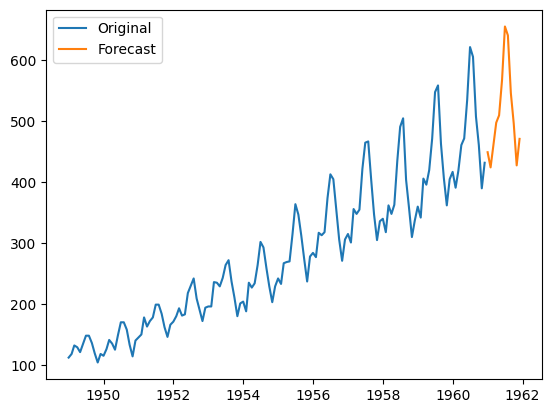

In [15]:
#Question 8: Train SARIMA model on AirPassengers

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

df = pd.read_csv('AirPassengers.csv', parse_dates=['Month'], index_col='Month')

model = SARIMAX(df['#Passengers'], order=(1,1,1), seasonal_order=(1,1,1,12))
results = model.fit()

forecast = results.forecast(steps=12)

plt.plot(df.index, df['#Passengers'], label='Original')
plt.plot(forecast.index, forecast, label='Forecast')
plt.legend()
plt.show()


/tmp/ipython-input-203/33718088.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'pickup_datetime': pd.date_range(start='2023-01-01', periods=rows, freq='H'),
/tmp/ipython-input-203/33718088.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'dropoff_datetime': pd.date_range(start='2023-01-01 00:20', periods=rows, freq='H'),


Sample dataset created: nyc_trip_sample.csv


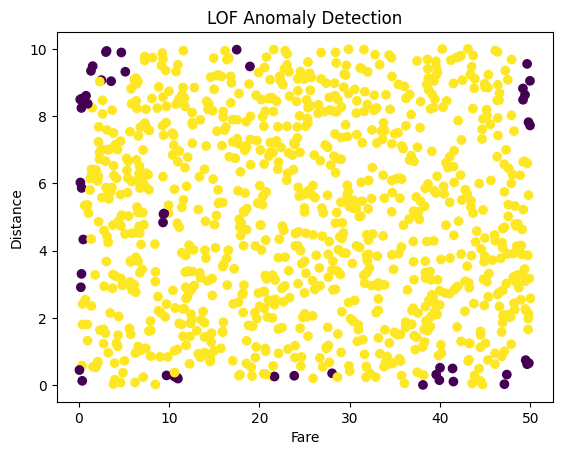

In [17]:
#Question 9: Apply LOF

from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt
import pandas as pd

rows = 1000
df = pd.DataFrame({
    'pickup_datetime': pd.date_range(start='2023-01-01', periods=rows, freq='H'),
    'dropoff_datetime': pd.date_range(start='2023-01-01 00:20', periods=rows, freq='H'),
    'passenger_count': np.random.randint(1, 5, rows),
    'trip_distance': np.random.rand(rows) * 10,
    'fare_amount': np.random.rand(rows) * 50,
    'tip_amount': np.random.rand(rows) * 10,
    'total_amount': lambda x: x['fare_amount'] + x['tip_amount']
})

df.to_csv("nyc_trip_sample.csv", index=False)
print("Sample dataset created: nyc_trip_sample.csv")

X = df[['fare_amount', 'trip_distance']]

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df['lof_anomaly'] = lof.fit_predict(X)

plt.scatter(df['fare_amount'], df['trip_distance'], c=df['lof_anomaly'])
plt.xlabel('Fare')
plt.ylabel('Distance')
plt.title('LOF Anomaly Detection')
plt.show()

#Question 10: Real-Time Data Science Workflow (Power Grid Monitoring)
- Answer:
1.Anomaly Detection

Use Isolation Forest for streaming data because:

Works efficiently on large data

Detects global anomalies

Can be retrained periodically

For density-based anomaly detection in localized regions → LOF

2.Forecasting Model

Use SARIMAX because:

Data is seasonal (15-minute intervals)

Weather impacts energy usage (exogenous variable)

3.Validation & Monitoring

Rolling window cross-validation

RMSE / MAE monitoring

Real-time alert system

Model retraining every week/month

4.Business Impact

Prevent grid failures

Detect power theft

Improve load balancing

Optimize energy production

Reduce operational cost